<a href="https://colab.research.google.com/github/Lucaaa31/Anomaly-Segmentation/blob/master/Step4_Eomt_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 4: EoMT Evaluation on Cityscapes val

Compare the two EoMT checkpoints on Cityscapes val:

* **EoMT-CS** (Cityscapes-trained, semantic, 19 classes): direct predictions
* **EoMT-COCO** (COCO-trained, panoptic, 133 classes): panoptic predictions + semantic remapping to Cityscapes

Output: 1) qualitative visualizations on sample images, 2) quantitative mIoU for both.


## 1. Mount Drive and environment setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Colab_Projects/Anomaly-Segmentation
!git pull origin master

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab_Projects/Anomaly-Segmentation
From https://github.com/Lucaaa31/Anomaly-Segmentation
 * branch            master     -> FETCH_HEAD
Already up to date.


## 2. Install dependencies

We install directly in Colab's Python (no conda). Only the dependencies needed for the vendored EoMT inference, no `jsonargparse`, `gitignore_parser` or `wandb login`.

In [ ]:
!pip install -q -r requirements.txt

## 3. Imports and path

In [ ]:
import sys
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path("/content/drive/MyDrive/Colab_Projects/Anomaly-Segmentation")
EOMT_DIR  = REPO_ROOT / "models" / "eomt"
DATA_PATH = REPO_ROOT / "dataset" / "Cityscapes"

# Repo root must be on sys.path so the `utils.X` modules resolve; models/eomt/
# must be on sys.path so the YAML class_path entries (e.g. `datasets.cityscapes_semantic`,
# `training.mask_classification_semantic`, `models.eomt`, `models.vit`) resolve.
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(EOMT_DIR))

# Reusable helpers from the project subpackage. The utils/ folder is split by concern:
#   utils.build         -> build_model_and_data
#   utils.inference     -> infer_semantic_logits, infer_panoptic
#   utils.class_remap   -> build_coco_to_cs_lut (COCO panoptic id -> CS train_id)
#   utils.visualize     -> colorize_cs, panoptic_to_rgb (and *_vis savers)
#   utils.eval_semantic -> per_pixel_target, evaluate_semantic, print_iou_table, CS_CLASS_NAMES
from utils.build import build_model_and_data
from utils.inference import infer_semantic_logits, infer_panoptic
from utils.class_remap import build_coco_to_cs_lut
from utils.visualize import colorize_cs, panoptic_to_rgb
from utils.eval_semantic import (
    per_pixel_target, evaluate_semantic, print_iou_table, CS_CLASS_NAMES,
)
# Cityscapes data module from the EoMT subtree at models/eomt/datasets/.
from datasets.cityscapes_semantic import CityscapesSemantic

assert torch.cuda.is_available(), \
    "Enable GPU runtime: Runtime → Change runtime type → T4 GPU"
device = torch.device("cuda")
print("device:", device, "| torch:", torch.__version__)

## 4. Load the two checkpoints

We use `build_model_and_data` from [utils/eval_semantic.py](utils/eval_semantic.py): it reads the YAML config, instantiates encoder + network + Lightning module via `importlib`, and loads the `.bin` weights, same code path as the CLI. We pass `setup_data=False` so the data module returns only metadata (`num_classes`, `img_size`, `stuff_classes`) without trying to open the COCO zips.

In [ ]:
cs_config = REPO_ROOT / "configs" / "dinov2" / "cityscapes" / "semantic" / "eomt_base_640.yaml"
cs_ckpt   = REPO_ROOT / "models" / "eomt_cityscapes.bin"
print("Building Cityscapes-trained EoMT-")
cs_model, cs_meta = build_model_and_data(cs_config, cs_ckpt, DATA_PATH, device, setup_data=False)
print(f"  num_classes={cs_meta.num_classes}  img_size={cs_meta.img_size}")

In [ ]:
coco_config = REPO_ROOT / "configs" / "dinov2" / "coco" / "panoptic" / "eomt_base_640_2x.yaml"
coco_ckpt   = REPO_ROOT / "models" / "eomt_coco.bin"
print("Building COCO-trained EoMT-")
coco_model, coco_meta = build_model_and_data(coco_config, coco_ckpt, DATA_PATH, device, setup_data=False)
print(f"  num_classes={coco_meta.num_classes}  img_size={coco_meta.img_size}")

## 5. Load the Cityscapes val dataset

Read directly from the two zips: `leftImg8bit_trainvaltest.zip` and `gtFine_trainvaltest.zip`. `CityscapesSemantic` is imported from the vendored EoMT subtree ([eomt/datasets/cityscapes_semantic.py](eomt/datasets/cityscapes_semantic.py)). Change `img_idx` to explore different images.

In [6]:
print("Loading Cityscapes val dataset (from zips)")
cs_data = CityscapesSemantic(
    path=str(DATA_PATH), batch_size=1, num_workers=0, check_empty_targets=False,
).setup()
val_dataset = cs_data.val_dataloader().dataset
print(f"  {len(val_dataset)} validation images")

img_idx = -1   # <-- switch for different images
img, target_dict = val_dataset[img_idx]
print(f"image {img_idx}: shape={tuple(img.shape)}  "
      f"GT classes={sorted(target_dict['labels'].tolist())}")

Loading Cityscapes val dataset (from zips)
  500 validation images
image -1: shape=(3, 1024, 2048)  GT classes=[0, 2, 3, 4, 5, 7, 8, 10, 13]


## 6. Semantic prediction of the CS-trained model

Three panels: image, prediction, ground truth. Colors come from `colorize_cs` (Cityscapes 19-class palette, with `ignore_index=255` mapped to black).

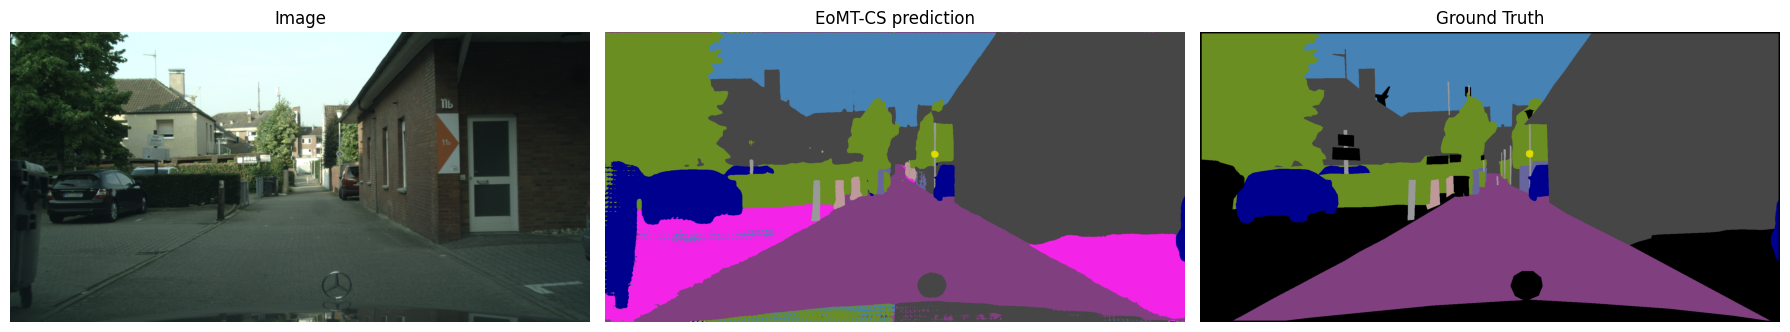

In [7]:
logits  = infer_semantic_logits(cs_model, img, device)
pred_cs = logits.argmax(0).cpu().numpy()
target  = per_pixel_target(target_dict).cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
axes[0].set_title("Image")
axes[1].imshow(colorize_cs(pred_cs))
axes[1].set_title("EoMT-CS prediction")
axes[2].imshow(colorize_cs(target))
axes[2].set_title("Ground Truth")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

## 7. Panoptic prediction of the COCO-trained model

Panoptic output: each pixel has both a semantic class (out of the 133 from COCO) and an instance id. The RGB rendering (random hue per class + black borders between segments) is built by `panoptic_to_rgb`, the same helper used by the CLI.

unique semantic classes in panoptic prediction: [2, 86, 91, 116, 119, 123, 133]


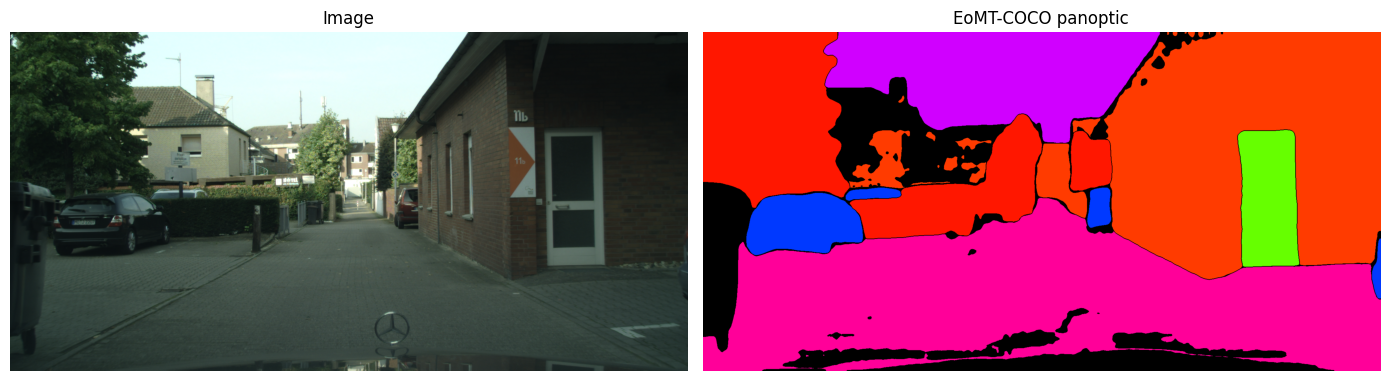

In [8]:
sem, inst = infer_panoptic(coco_model, img, device)
print(f"unique semantic classes in panoptic prediction: {np.unique(sem).tolist()}")

panoptic_rgb = panoptic_to_rgb(sem, inst, coco_meta.num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img.permute(1, 2, 0).cpu().numpy()); axes[0].set_title("Image")
axes[1].imshow(panoptic_rgb);                       axes[1].set_title("EoMT-COCO panoptic")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

## 8. COCO to Cityscapes: remapping for comparison

To compare the two networks on the same metric, a mapping from COCO continuous id to Cityscapes train_id is needed. The `COCO_TO_CS` dictionary and `build_coco_to_cs_lut` helper live in [utils/eval_semantic.py](utils/eval_semantic.py). Unmappable COCO classes (e.g., `pole`, `rider`) end up as `255` (ignore): in the mIoU, those pixels will not be counted. "Strict" approach: no free credit for what we cannot translate.

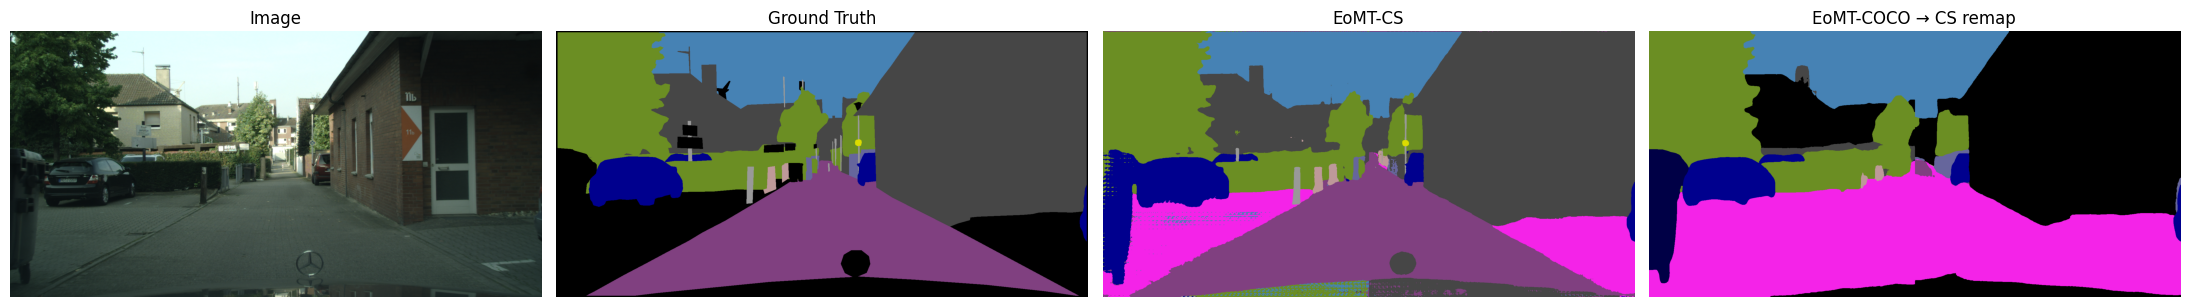

In [9]:
logits_coco = infer_semantic_logits(coco_model, img, device)   # [133, H, W]
lut = build_coco_to_cs_lut(coco_meta.num_classes, device)
pred_coco_remap = lut[logits_coco.argmax(0)].cpu().numpy()     # {0..18, 255}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(img.permute(1,2,0).cpu().numpy());  axes[0].set_title("Image")
axes[1].imshow(colorize_cs(target));               axes[1].set_title("Ground Truth")
axes[2].imshow(colorize_cs(pred_cs));              axes[2].set_title("EoMT-CS")
axes[3].imshow(colorize_cs(pred_coco_remap));      axes[3].set_title("EoMT-COCO → CS remap")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

## 9. Quantitative: mIoU on Cityscapes val (strict + common)

Full loop on val (500 images) using `evaluate_semantic` from [utils/eval_semantic.py](utils/eval_semantic.py). For the COCO model we pass the LUT so predictions are remapped to Cityscapes train_ids before scoring (unmappable predictions are sent to ignore).

We evaluate both **label spaces** in a single pass over the dataset:

* **strict** - full 19 CS classes in the GT. Fair to the CS-trained model; harsh on the COCO-trained one (rider/pole always score 0; traffic sign only gets credit on stop signs).
* **common** - GT is reduced to the intersection of the two class spaces: `pole` and `traffic sign` are dropped (set to ignore in the GT) and `rider` is merged into `person`. Predictions get the same rider→person merge so a correct rider prediction counts as a correct person. mIoU is reported over the remaining 16 classes - fairer cross-dataset comparison.

Pass `label_space=("strict","common")` to compute both metrics in one forward pass; the result is a `{space: per_class_iou}` dict. For a quick sanity check set `MAX_IMAGES=50`; for the official numbers set it to `-1`.

In [10]:
MAX_IMAGES = 50  # -1 for all 500 val images
LABEL_SPACES = ("strict", "common")

print(f"--- EoMT-CS on Cityscapes val (max_images={MAX_IMAGES}) ---")
iou_cs = evaluate_semantic(
    cs_model, val_dataset, device,
    label_space=LABEL_SPACES, max_images=MAX_IMAGES, vis_prefix="cs",
)
for space in LABEL_SPACES:
    print_iou_table(f"EoMT-CS [{space}]", iou_cs[space])

--- EoMT-CS on Cityscapes val (max_images=50) ---
  cs 50/50

=== EoMT-CS [strict] ===
class                IoU
-------------------------
road              98.43
sidewalk          86.00
building          92.78
wall              48.92
fence             64.28
pole              73.16
traffic light     69.71
traffic sign      81.92
vegetation        92.70
terrain           64.91
sky               95.49
person            79.92
rider             74.42
car               95.60
truck             95.30
bus               90.11
train             64.88
motorcycle        81.82
bicycle           80.44
-------------------------
mIoU              80.57  (19 cls)

=== EoMT-CS [common] ===
class                IoU
-------------------------
road              98.46
sidewalk          86.41
building          93.55
wall              49.28
fence             65.75
pole                  —
traffic light     73.01
traffic sign          —
vegetation        93.47
terrain           67.76
sky               95.87
perso

In [11]:
print(f"--- EoMT-COCO (remapped) on Cityscapes val (max_images={MAX_IMAGES}) ---")
lut = build_coco_to_cs_lut(coco_meta.num_classes, device)
iou_coco = evaluate_semantic(
    coco_model, val_dataset, device, lut=lut,
    label_space=LABEL_SPACES, max_images=MAX_IMAGES, vis_prefix="coco",
)
for space in LABEL_SPACES:
  print_iou_table(f"EoMT-COCO [{space}]", iou_coco[space])

--- EoMT-COCO (remapped) on Cityscapes val (max_images=50) ---
  coco 50/50

=== EoMT-COCO [strict] ===
class                IoU
-------------------------
road              96.79
sidewalk          73.60
building          85.79
wall              32.96
fence             58.24
pole               0.00
traffic light     56.29
traffic sign       7.53
vegetation        87.40
terrain           55.40
sky               90.05
person            66.17
rider              0.00
car               82.82
truck             56.06
bus               69.91
train             21.01
motorcycle        70.86
bicycle           72.23
-------------------------
mIoU              57.01  (19 cls)

=== EoMT-COCO [common] ===
class                IoU
-------------------------
road              97.00
sidewalk          77.40
building          90.62
wall              34.87
fence             61.63
pole                  —
traffic light     59.45
traffic sign          —
vegetation        91.95
terrain           60.11
sky       

## 10. Final comparison

Side-by-side per-class IoU for both models under both label spaces. Expected pattern:

* **EoMT-CS** wins under both spaces - same training class set, argmax in the same space.
* **EoMT-COCO** loses heavily under **strict** on `pole`/`rider` (always 0, no COCO equivalent) and `traffic sign` (only stop signs are recognized).
* Under **common** these classes are dropped/merged from the GT, so the COCO mIoU recovers a few points and the gap with EoMT-CS narrows - the residual gap is the "honest" cross-dataset gap, free of class-space penalty.

Mean is taken only over classes that contribute (NaN-skipping), so the strict mIoU is over 19 classes and the common mIoU over ~16 (number printed next to each).

In [12]:
def _fmt(v):
    return "    -  " if v != v else f"{v*100:>7.2f}"

def _miou(iou):
    valid = iou[~torch.isnan(iou)]
    return valid.mean().item() * 100, valid.numel()

cols = [
    ("CS-strict",   iou_cs["strict"]),
    ("CS-common",   iou_cs["common"]),
    ("COCO-strict", iou_coco["strict"]),
    ("COCO-common", iou_coco["common"]),
]

header = f"{'class':<16}" + "".join(f" {name:>11}" for name, _ in cols)
print(header)
print("-" * len(header))
for i, c in enumerate(CS_CLASS_NAMES):
    row = f"{c:<16}" + "".join(f" {_fmt(iou[i].item()):>11}" for _, iou in cols)
    print(row)
print("-" * len(header))

miou_row = f"{'mIoU':<16}"
ncls_row = f"{'(# classes)':<16}"
for _, iou in cols:
    m, k = _miou(iou)
    miou_row += f" {m:>10.2f} "
    ncls_row += f" {k:>10d} "
print(miou_row)
print(ncls_row)

class              CS-strict   CS-common COCO-strict COCO-common
----------------------------------------------------------------
road                   98.43       98.46       96.79       97.00
sidewalk               86.00       86.41       73.60       77.40
building               92.78       93.55       85.79       90.62
wall                   48.92       49.28       32.96       34.87
fence                  64.28       65.75       58.24       61.63
pole                   73.16         -          0.00         -  
traffic light          69.71       73.01       56.29       59.45
traffic sign           81.92         -          7.53         -  
vegetation             92.70       93.47       87.40       91.95
terrain                64.91       67.76       55.40       60.11
sky                    95.49       95.87       90.05       92.63
person                 79.92       81.88       66.17       80.29
rider                  74.42         -          0.00         -  
car                    95